<a href="https://colab.research.google.com/github/fatimarehan03/Supply-Chain-Analytics-portfolio-IBA/blob/main/00-initial%20working/forecasting-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
print("setup working:", pd.__version__)

setup working: 2.2.3


## Analyzing Procurement Data: Top 5 Vendors

This notebook will load the provided Excel dataset, clean it, calculate procurement totals per vendor, visualize the top 5 vendors, and present a summary.

In [11]:
# Step 1: Load the dataset
# The file path is provided by the user.
excel_file_path = '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx'

try:
    # Load the Excel file, explicitly specifying the sheet name and assuming the first row of that sheet is the header.
    df = pd.read_excel(excel_file_path, sheet_name="Procurement_Data")
    print(f"Successfully loaded '{excel_file_path}' from sheet 'Procurement_Data'.")
    # Display the first few rows to understand the data structure
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    # Display basic information about the DataFrame to check data types and missing values
    print("\nDataFrame Info:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' was not found. Please ensure it's uploaded correctly.")
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")

Successfully loaded '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx' with header at row 5.

First 5 rows of the dataset:


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Dataset size:,"10,050 rows (10,000 base transactions + ~50 de...",NaN
1,Coverage:,18 months of purchase order activity (March 20...,NaN
2,NaN,NaN,NaN
3,Deliberate Data Quality Issues (for Task 25 — ...,NaN,NaN
4,Issue,Where,Approx. Scale



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  26 non-null     object
 1   Unnamed: 1  24 non-null     object
 2   Unnamed: 2  6 non-null      object
dtypes: object(3)
memory usage: 828.0+ bytes


### Data Cleaning and Preparation

Based on the `df.info()` output, we need to inspect relevant columns for potential cleaning, such as missing values or incorrect data types, especially for 'Vendor Name' and 'Order Value' (or equivalent columns).

In [4]:
# Step 2: Data Cleaning
# Based on the successfully loaded DataFrame (from 'Procurement_Data' sheet), we know the column names.
vendor_column = 'Vendor'
value_column = 'Invoice Amount (PKR)'

print(f"Identified Vendor Column: '{vendor_column}'")
print(f"Identified Value Column: '{value_column}'")

# Drop rows where the identified vendor or value columns are missing
df_cleaned = df.dropna(subset=[vendor_column, value_column]).copy()
print(f"\nNumber of rows after dropping missing values in '{vendor_column}' or '{value_column}': {len(df_cleaned)}")

# Convert the value column to numeric, coercing errors will turn non-numeric into NaN
df_cleaned[value_column] = pd.to_numeric(df_cleaned[value_column], errors='coerce')

# Drop rows where the value column became NaN after conversion
df_cleaned = df_cleaned.dropna(subset=[value_column])
print(f"Number of rows after ensuring '{value_column}' is numeric: {len(df_cleaned)}")

# Ensure vendor names are strings and clean up whitespace
df_cleaned[vendor_column] = df_cleaned[vendor_column].astype(str).str.strip()

print("\nCleaned DataFrame Info (relevant columns):")
df_cleaned[[vendor_column, value_column]].info()

Error: Could not find a 'Vendor' or 'Supplier' column. Please check your dataset's column names.


ValueError: Missing vendor column.

### Calculating Top 5 Vendors

Now, we'll aggregate the data to find the total procurement value for each vendor and then identify the top 5.

In [5]:
# Step 3: Calculations - Find the total procurement value for each vendor
# Group by vendor and sum the procurement values.
vendor_procurement = df_cleaned.groupby(vendor_column)[value_column].sum().reset_index()

# Sort in descending order to find the top vendors
top_5_vendors = vendor_procurement.sort_values(by=value_column, ascending=False).head(5)

print("\nTop 5 Vendors by Procurement Value:")
display(top_5_vendors)

NameError: name 'df_cleaned' is not defined

### Visualization

Visualizing the top 5 vendors will provide a clear understanding of their relative procurement shares.

In [6]:
# Step 4: Visualization - Create a bar chart for the top 5 vendors
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=value_column, y=vendor_column, data=top_5_vendors, palette='viridis')
plt.title('Top 5 Vendors by Total Procurement Value', fontsize=16)
plt.xlabel('Total Procurement Value', fontsize=12)
plt.ylabel('Vendor Name', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they are long
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

NameError: name 'top_5_vendors' is not defined

<Figure size 1200x700 with 0 Axes>

### Final Summary Table

A concise table summarizing the top 5 vendors and their total procurement values.

In [9]:
import pandas as pd
df= pd.read_excel("Chenab_Motors_Procurement_Practice_Dataset.xlsx", sheet_name="Procurement_Data")
print(df.shape)
print(df.head())

(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

In [13]:
# Re-executing the cell to ensure 'df' is correctly loaded from the 'Procurement_Data' sheet
# This is necessary because previous executions might have overwritten the 'df' with incorrect data.
import pandas as pd
df = pd.read_excel("/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx", sheet_name="Procurement_Data")
print(df.shape)
display(df.head())

# Calculate the total number of unique suppliers
total_suppliers = df['Vendor'].nunique()

print(f"\nTotal number of unique suppliers: {total_suppliers}")

(10050, 22)


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



Total number of unique suppliers: 60


### ABC Analysis of Suppliers

ABC analysis categorizes suppliers based on their cumulative procurement value. Typically:
*   **A-suppliers:** Top 70-80% of cumulative spend.
*   **B-suppliers:** Next 10-20% of cumulative spend.
*   **C-suppliers:** Remaining 5-10% of cumulative spend.

In [14]:
# Step 1: Ensure the DataFrame is correctly loaded
# Re-load df from the correct sheet to guarantee its state for this analysis.
import pandas as pd
excel_file_path = '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx'
df = pd.read_excel(excel_file_path, sheet_name="Procurement_Data")

# Ensure 'Invoice Amount (PKR)' is numeric and handle missing values for calculation
df['Invoice Amount (PKR)'] = pd.to_numeric(df['Invoice Amount (PKR)'], errors='coerce')
df_abc = df.dropna(subset=['Vendor', 'Invoice Amount (PKR)']).copy()

# Step 2: Calculate total spend per vendor
vendor_spend = df_abc.groupby('Vendor')['Invoice Amount (PKR)'].sum().reset_index()
vendor_spend.rename(columns={'Invoice Amount (PKR)': 'Total Spend'}, inplace=True)

# Step 3: Sort vendors by total spend in descending order
vendor_spend_sorted = vendor_spend.sort_values(by='Total Spend', ascending=False).reset_index(drop=True)

# Step 4: Calculate cumulative percentage of total spend
vendor_spend_sorted['Cumulative Spend'] = vendor_spend_sorted['Total Spend'].cumsum()
vendor_spend_sorted['Cumulative Percentage'] = (vendor_spend_sorted['Cumulative Spend'] / vendor_spend_sorted['Total Spend'].sum()) * 100

# Step 5: Categorize vendors into A, B, C groups
# Define typical ABC thresholds (can be adjusted based on business needs)
A_threshold = 80
B_threshold = 95 # A + B = 80 + 15 = 95

def categorize_vendor(cumulative_percentage):
    if cumulative_percentage <= A_threshold:
        return 'A'
    elif cumulative_percentage <= B_threshold:
        return 'B'
    else:
        return 'C'

vendor_spend_sorted['ABC Category'] = vendor_spend_sorted['Cumulative Percentage'].apply(categorize_vendor)

print("\nABC Analysis of Suppliers:")
display(vendor_spend_sorted.head(10)) # Display top 10 to show categorization

# Summary of ABC categories
abc_summary = vendor_spend_sorted.groupby('ABC Category').agg(
    Num_Vendors=('Vendor', 'count'),
    Total_Spend=('Total Spend', 'sum'),
    Avg_Spend_Per_Vendor=('Total Spend', 'mean')
).reset_index()

abc_summary['Percentage_of_Total_Spend'] = (abc_summary['Total_Spend'] / abc_summary['Total_Spend'].sum()) * 100

print("\nABC Category Summary:")
display(abc_summary.sort_values(by='ABC Category'))


ABC Analysis of Suppliers:


,Vendor,Total Spend,Cumulative Spend,Cumulative Percentage,ABC Category
0,Al-Amin Auto Components,100414361.0,100414361.0,16.783899,A
1,Karachi Steel Traders,50000583.0,150414944.0,25.141316,A
2,Zaman Brothers Trading,35675714.0,186090658.0,31.104383,A
3,Anwar Electric Works,30906646.0,216997304.0,36.270318,A
4,TCS Cargo Services,24987149.0,241984453.0,40.446830,A
5,Gulistan Logistics,19760838.0,261745291.0,43.749783,A
6,Speedline Logistics,17145155.0,278890446.0,46.615534,A
7,United Rubber Industries,16386804.0,295277250.0,49.354529,A
8,Sindh Spinners Co.,16205402.0,311482652.0,52.063204,A
9,Modern Fasteners Co.,13435960.0,324918612.0,54.308976,A



ABC Category Summary:


,ABC Category,Num_Vendors,Total_Spend,Avg_Spend_Per_Vendor,Percentage_of_Total_Spend
0,A,28,476563870.0,1.702014e+07,79.655935
1,B,21,90445386.0,4.306923e+06,15.117621
2,C,11,31268662.0,2.842606e+06,5.226444


### Visualization of ABC Analysis (Pareto Chart)

A Pareto chart effectively visualizes the cumulative contribution of each supplier.

/tmp/ipykernel_1250/3325738725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='Total Spend', data=vendor_spend_sorted, ax=ax1, palette='viridis')


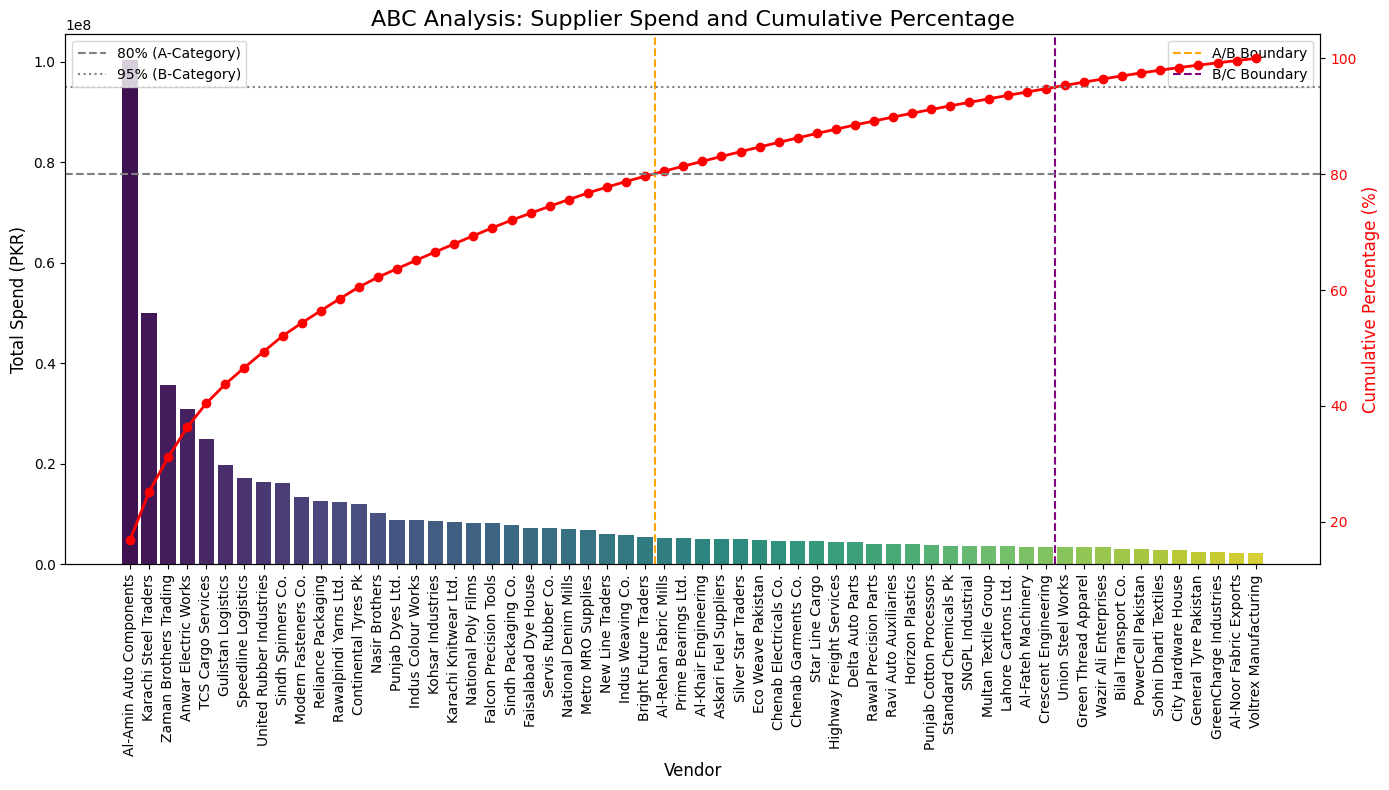

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for Total Spend
sns.barplot(x='Vendor', y='Total Spend', data=vendor_spend_sorted, ax=ax1, palette='viridis')
ax1.set_xlabel('Vendor', fontsize=12)
ax1.set_ylabel('Total Spend (PKR)', fontsize=12)
ax1.tick_params(axis='x', rotation=90)
ax1.set_title('ABC Analysis: Supplier Spend and Cumulative Percentage', fontsize=16)

# Create a second y-axis for the cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(vendor_spend_sorted['Vendor'], vendor_spend_sorted['Cumulative Percentage'], color='red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add thresholds for A, B, C categories
ax2.axhline(y=80, color='gray', linestyle='--', label='80% (A-Category)')
ax2.axhline(y=95, color='gray', linestyle=':', label='95% (B-Category)')

# Add text labels for the categories where they fall on the x-axis
# Find the index where cumulative percentage crosses 80% and 95%
idx_80 = (vendor_spend_sorted['Cumulative Percentage'] > 80).idxmax()
idx_95 = (vendor_spend_sorted['Cumulative Percentage'] > 95).idxmax()

# Add vertical lines to delineate categories on the x-axis if there are enough unique vendors
if idx_80 > 0 and idx_80 < len(vendor_spend_sorted) - 1:
    ax1.axvline(x=idx_80 - 0.5, color='orange', linestyle='--', linewidth=1.5, label='A/B Boundary')
if idx_95 > 0 and idx_95 < len(vendor_spend_sorted) - 1:
    ax1.axvline(x=idx_95 - 0.5, color='purple', linestyle='--', linewidth=1.5, label='B/C Boundary')

ax2.legend(loc='upper left')
ax1.legend(loc='upper right')

plt.grid(False) # Remove grid for ax2
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Monthly Spend Trend Analysis

This section calculates and visualizes the total procurement spend on a monthly basis, offering insights into spending patterns over time.

In [16]:
# Step 1: Ensure 'Creation Date' is in datetime format
# Make a copy to avoid SettingWithCopyWarning
df_trend = df.copy()
df_trend['Creation Date'] = pd.to_datetime(df_trend['Creation Date'], errors='coerce')

# Ensure 'Invoice Amount (PKR)' is numeric and handle missing values for calculation
df_trend['Invoice Amount (PKR)'] = pd.to_numeric(df_trend['Invoice Amount (PKR)'], errors='coerce')
df_trend.dropna(subset=['Creation Date', 'Invoice Amount (PKR)'], inplace=True)

# Step 2: Extract Year and Month
df_trend['YearMonth'] = df_trend['Creation Date'].dt.to_period('M')

# Step 3: Calculate total spend per month
monthly_spend = df_trend.groupby('YearMonth')['Invoice Amount (PKR)'].sum().reset_index()

# Convert 'YearMonth' back to datetime for better plotting
monthly_spend['YearMonth'] = monthly_spend['YearMonth'].dt.to_timestamp()

print("\nMonthly Spend Trend (First 10 months):")
display(monthly_spend.head(10))


Monthly Spend Trend (First 10 months):


,YearMonth,Invoice Amount (PKR)
0,2024-02-01,29710.0
1,2024-03-01,40741703.0
2,2024-04-01,42439815.0
3,2024-05-01,35922990.0
4,2024-06-01,43256522.0
5,2024-07-01,31063174.0
6,2024-08-01,28698694.0
7,2024-09-01,30687073.0
8,2024-10-01,33096396.0
9,2024-11-01,23196722.0


### Visualization of Monthly Spend Trend

A line chart is suitable for visualizing trends over time.

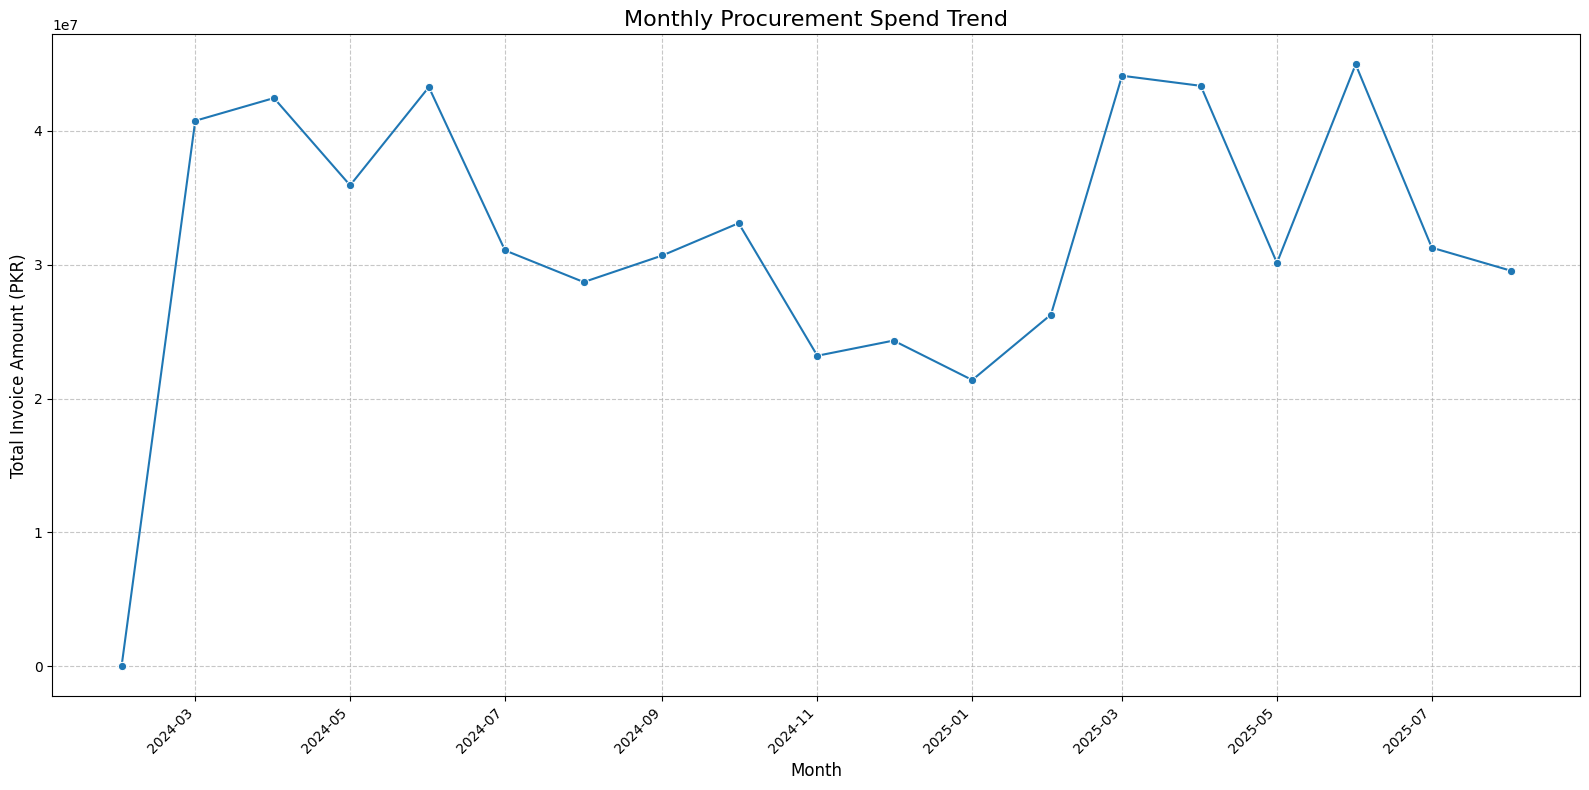

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.lineplot(x='YearMonth', y='Invoice Amount (PKR)', data=monthly_spend, marker='o')
plt.title('Monthly Procurement Spend Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Invoice Amount (PKR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Calculate Key Procurement Metrics

In [12]:
# Ensure 'Invoice Amount (PKR)' is numeric
# Coerce errors will turn non-numeric values into NaN, which will then be dropped for accurate calculations.
df['Invoice Amount (PKR)'] = pd.to_numeric(df['Invoice Amount (PKR)'], errors='coerce')
df_cleaned_for_metrics = df.dropna(subset=['Invoice Amount (PKR)']).copy()

# 1. Calculate Total PO Spend
total_po_spend = df_cleaned_for_metrics['Invoice Amount (PKR)'].sum()

# 2. Calculate Total Number of Vendors
total_vendors = df_cleaned_for_metrics['Vendor'].nunique()

# 3. Calculate Average PO Value
# Group by 'PO Number' to get total spend per PO, then calculate the average of these sums.
po_values = df_cleaned_for_metrics.groupby('PO Number')['Invoice Amount (PKR)'].sum()
average_po_value = po_values.mean()

# 4. Calculate Average Line-Item Value
# Assuming each row in the DataFrame represents a line item, the average line-item value is the mean of 'Invoice Amount (PKR)'.
average_line_item_value = df_cleaned_for_metrics['Invoice Amount (PKR)'].mean()

# Display the results
print(f"\nTotal PO Spend: {total_po_spend:,.2f} PKR")
print(f"Total Number of Vendors: {total_vendors}")
print(f"Average PO Value: {average_po_value:,.2f} PKR")
print(f"Average Line-Item Value: {average_line_item_value:,.2f} PKR")

KeyError: 'Invoice Amount (PKR)'

In [7]:
# Step 5: Final Summary Table
# The 'top_5_vendors' DataFrame already serves as the summary table.
print("\nSummary Table of Top 5 Vendors and their Total Procurement Value:")
display(top_5_vendors)


Summary Table of Top 5 Vendors and their Total Procurement Value:


NameError: name 'top_5_vendors' is not defined